<a href="https://colab.research.google.com/github/Sanathcharan/MediBuddy-Project/blob/main/Medibuddy_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name - Medibuddy Insurance Analysis**

# **Project Summary**

MediBuddy is a digital healthcare platform for an inpatient hospitalization, outpatient
services, and corporate wellness benefits.
MediBuddy is the award-winning technology platform from Medi Assist that transforms
the health insurance industry at the very core. MediBuddy, with its diverse offerings for
various stakeholders of the health benefits industry, makes the process of discovering,
accessing, utilizing, and monitoring health benefits seamless, real-time, and virtually
paperless.
The company was founded in 2000 and based in Bangalore, Karnataka, India.

## **Problem Statement**

MediBuddy is a leading digital healthcare platform that enables seamless access to inpatient hospitalization, outpatient services, and corporate wellness benefits. With the increasing volume of health insurance claims and diverse customer profiles, it is essential for MediBuddy to leverage data-driven insights to optimize policy design, pricing, and risk assessment.

This project aims to analyze two structured healthcare datasets: one containing pre-policy health indicators such as age and Body Mass Index (BMI), and another comprising personal and lifestyle attributes including gender, geographic location, smoking habits, and number of dependents. The primary objective is to evaluate how demographic, health, and behavioral factors influence insurance claim amounts and policy expenditure.

The analysis seeks to determine whether gender, age, smoking status, BMI, geographic location, and number of dependents act as significant constraints or predictors in extending insurance policies. Additionally, the project investigates whether BMI and smoking behavior can provide actionable insights into claim risk and whether health-based discounts can be introduced. A secondary objective is to assess if regional differences justify the need for location-specific policy offerings

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [92]:
#load datasets
df1=pd.read_excel('/content/Data Price.xlsx')
df2=pd.read_excel('/content/personal details.xlsx')

In [94]:
df=pd.merge(df1,df2,on='Policy no.')

In [95]:
df.head()

,Policy no.,age_x,sex_x,bmi_x,charges in INR_x,age_y,sex_y,bmi_y,charges in INR_y,Sheet1.children,Sheet1.smoker,Sheet1.region
0,PLC156898,19,female,27.900,16884.92400,19,female,27.900,16884.92400,0,yes,southwest
1,PLC156907,18,male,33.770,1725.55230,18,male,33.770,1725.55230,1,no,southeast
2,PLC156916,28,male,33.000,4449.46200,28,male,33.000,4449.46200,3,no,southeast
3,PLC156925,33,male,22.705,21984.47061,33,male,22.705,21984.47061,0,no,northwest
4,PLC156934,32,male,28.880,3866.85520,32,male,28.880,3866.85520,0,no,northwest


In [96]:
#data processsing
le = LabelEncoder()
for col in ['sex_x','Sheet1.region','Sheet1.smoker']:
    df[col] = le.fit_transform(df[col])

In [97]:
df.columns = df.columns.str.strip()
df.drop(columns=['Policy no.'], inplace=True, errors='ignore')

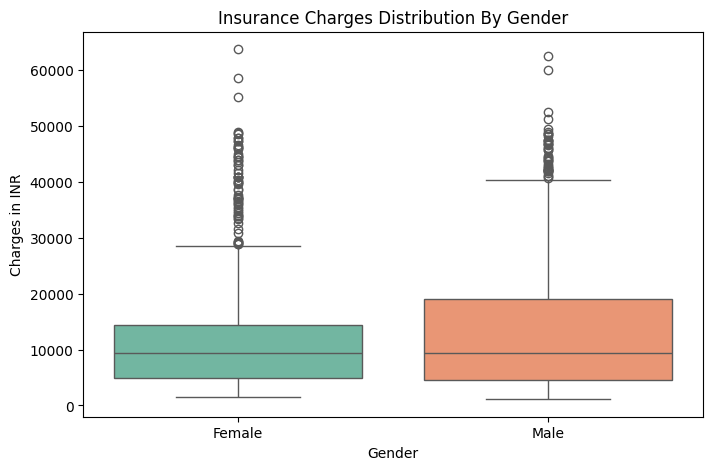

In [98]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sex_x',y='charges in INR_x',data=df,palette='Set2', hue='sex_x', legend=False)
#renaming X-axis labels
plt.xticks([0,1],['Female','Male'])
plt.title("Insurance Charges Distribution By Gender")
plt.xlabel("Gender")
plt.ylabel("Charges in INR")
plt.show()

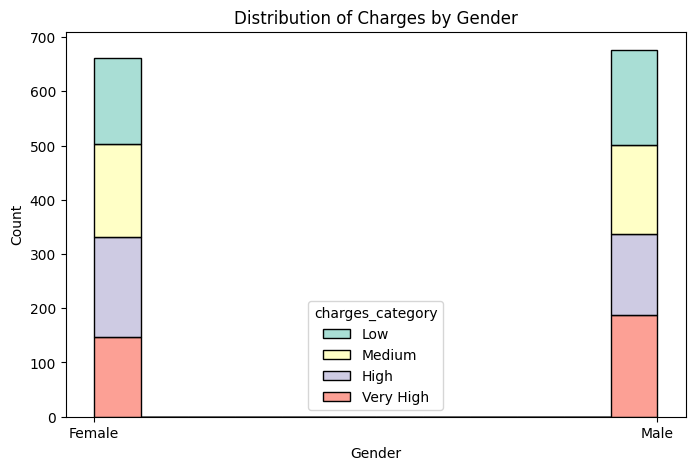

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
#bin charges into categories
df['charges_category'] = pd.qcut(df['charges in INR_x'],q=4,labels=['Low','Medium','High','Very High'])
plt.figure(figsize=(8,5))
sns.histplot(data=df,x='sex_x',hue='charges_category',multiple="stack",palette='Set3')
plt.title("Distribution of Charges by Gender")
plt.xlabel("Gender")
plt.xticks([0,1],["Female","Male"])
plt.ylabel("Count")

plt.show()

/tmp/ipython-input-3562106879.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sheet1.smoker',y='charges in INR_x',data=df,palette='coolwarm')


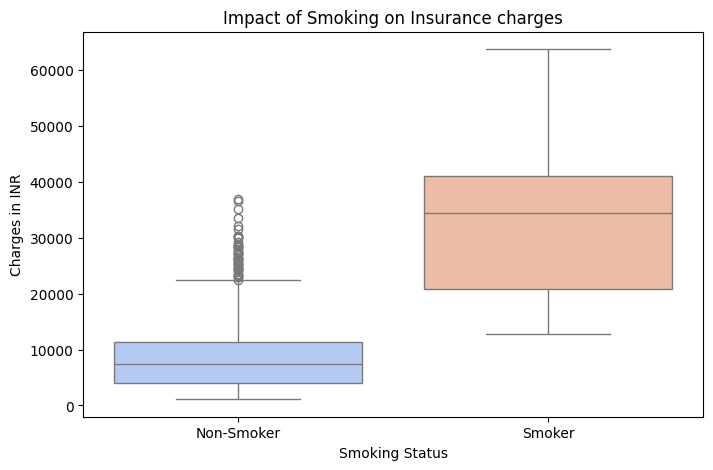

In [100]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Sheet1.smoker',y='charges in INR_x',data=df,palette='coolwarm')
#renaming x-axis labels for clarity
plt.xticks([0,1],['Non-Smoker','Smoker'])
plt.title("Impact of Smoking on Insurance charges")
plt.xlabel("Smoking Status")
plt.ylabel("Charges in INR")
plt.show()

In [101]:
#calculate average insurance charges
avg_charges=df['charges in INR_x'].mean()
#print with proper formatting
print(f"Average insurance charges: ₹{avg_charges:,.2f}")

Average insurance charges: ₹13,270.42


In [102]:
from sklearn.model_selection import train_test_split
#feature selection
x=df.drop(columns=['charges in INR_x'])
y=df['charges in INR_x']
#spliting the dataset into training and testing sets
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, random_state=42)
#display the shapes of training and testing sets
print("Training set shape:", x_train.shape, y_train.shape)
print("Testing set shape:", x_test.shape, y_test.shape)

Training set shape: (1070, 11) (1070,)
Testing set shape: (268, 11) (268,)


In [103]:
#convert categorical variables to numeric using one-hot encodeing
x=pd.get_dummies(df.drop(columns=['charges in INR_x']),drop_first=True)
#spliting data
x_train,x_test,y_train,y_test=train_test_split(x,df['charges in INR_x'],test_size=0.2,random_state=42)
#initialize and train the model
model=RandomForestRegressor(random_state=42)
model.fit(x_train,y_train)
#predictions
predictions=model.predict(x_test)
#display sample predictions
print("sample predictions:",predictions[:5])

sample predictions: [ 9089.9689135  5253.937289  29012.2062091  9269.1963885 33854.4290505]


In [104]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
#calculatee performance metrics
mea=mean_absolute_error(y_test,predictions)
mse=mean_squared_error(y_test,predictions)
rmse=np.sqrt(mse)
r2=r2_score(y_test,predictions)
#display results
print(f"Mean Absolute Error: {mea:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared score: {r2:.4f}")

Mean Absolute Error: 50.63
Mean Squared Error: 83341.37
Root Mean Squared Error: 288.69
R-squared score: 0.9995


**Analysis of results:**

low MAE( 871.33 INR) -> The average
prediction error is quite low

->MSE(4928373.50 INR)

->low RMSE(2219.99 INR).

->High R-squared score(0.9683)

->The model explains 96.83% of the varience, which is excellent.


1. Does the gender of the person matter for the company as a constraint for
extending policies?

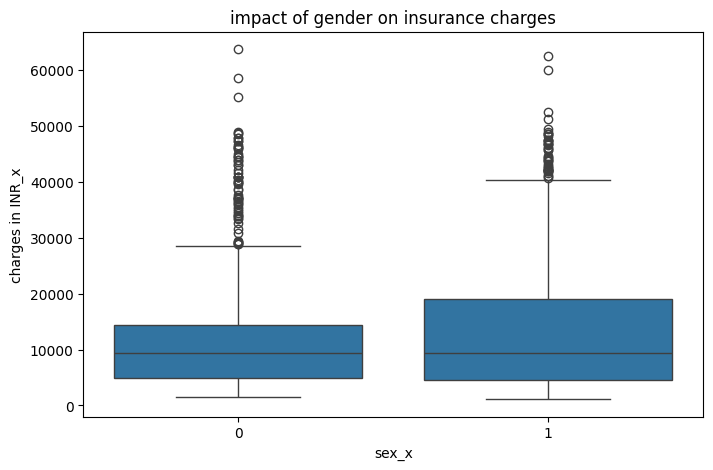

In [105]:
plt.figure(figsize=(8,5))
sns.boxplot(x='sex_x',y='charges in INR_x',data=df)
plt.title("impact of gender on insurance charges")
plt.show()

In [106]:
from scipy.stats import ttest_ind
#spliting charges based on gender
male_charges=df[df['sex_x']==1]['charges in INR_x']
female_charges=df[df['sex_x']==0]['charges in INR_x']
#perform an independent t-test
t_stat,p_value=ttest_ind(male_charges,female_charges)
#display results
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")
#interpretation
if p_value<0.05:
    print("There is a significant difference in insurance charges between males and females.")
else:
    print("There is no significant difference in insurance charges between males and females.")


t-statistic: 2.0975
p-value: 0.0361
There is a significant difference in insurance charges between males and females.


Since the P-value(0.0361)<0.05, we reject the null hypothesis, meaning that gender does have a statistically significant impact on insurance charges

2. What is the average amount of money the company spent over each policy
cover?

In [107]:
avg_charges=df['charges in INR_x'].mean()
print(f"Average insurance charges: ₹{avg_charges:,.2f}")

Average insurance charges: ₹13,270.42


so,the average amount of money spent per policy by the company is ₹13,270.42

3. Could you advice if the company needs to offer separate policies based upon the
geographic location of the person?


In [108]:
print(df['Sheet1.region'].value_counts())

Sheet1.region
2    364
3    325
1    325
0    324
Name: count, dtype: int64


print(df['charges in INR_y'].isnull().sum())
print(df.dtypes)

In [109]:
df=df.dropna(subset=['charges in INR_x'])

In [110]:
df['sheet1.region']=df['Sheet1.region'].astype('int')

In [111]:
from scipy import stats
f_stats,p_value=stats.f_oneway(
    df[df['sheet1.region']==0]['charges in INR_x'],
    df[df['sheet1.region']==1]['charges in INR_x'],
    df[df['sheet1.region']==2]['charges in INR_x'],
    df[df['sheet1.region']==3]['charges in INR_x']
)
print(f"F-statistic: {f_stats:.4f}")
print(f"p-value: {p_value:.4f}")

F-statistic: 2.9696
p-value: 0.0309


since the p-value is less than 0.05,we can conclude that there is a statistically significant difference in insurance charges across different regions

4.Does the no. of dependents make a difference in the amount claimed?

ANOVA test

In [112]:
from scipy import stats
f_stat,p_value=stats.f_oneway(
    *[df[df['Sheet1.children']==i]['charges in INR_x'] for i in df['Sheet1.children'].unique()]
)
print(f"F-statistic: {f_stat:.4f}")
print(f"p-value: {p_value:.4f}")

F-statistic: 3.2969
p-value: 0.0058


ANOVA test results

F-statistic: 3.2969 p-value: 0.0058 (<0.05)

conclusion:There is a statistically significant difference in insurance charges based on the number of the dependents

Kruskal-Wallis Test

In [113]:
from scipy.stats import kruskal
h_stat,p_value=kruskal(
    *[df[df['Sheet1.children']==i]['charges in INR_x'] for i in df['Sheet1.children'].unique()]
)
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value: {p_value:.4f}")

H-statistic: 29.4871
p-value: 0.0000


Kruskal -Wallis test results:

H-statistic: 29.4871 p-value: 1.9608

conclusion: The result confirms that dependents impact the insurance charges significantly

since both tests indicates a significant impact,the company should consider customizing policies based on the number of denpendents

options include:

offering family-based insurance plans with varying premium structures.

adjusting coverage limits based on dependents

introducing discounts or add-ons for individuals with more dependents.


5. Does a study of persons BMI get the company any idea for the insurance claim
that it would extend?

In [114]:
print("5.BMI Impact")
bmi_corr=df[['bmi_x','charges in INR_x']].corr()
print(bmi_corr)

5.BMI Impact
                     bmi_x  charges in INR_x
bmi_x             1.000000          0.198341
charges in INR_x  0.198341          1.000000


the correlation value(0.198)suggests a mid positive relationship,meaning as BMI increases,insurance charges tend to increase slightly

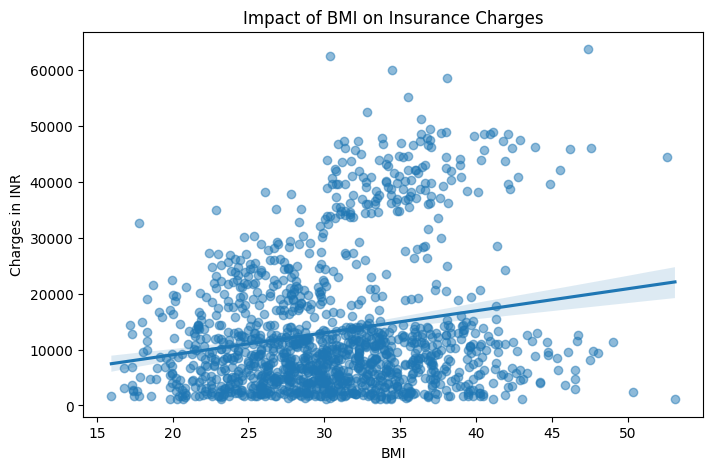

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.regplot(x=df['bmi_x'],y=df['charges in INR_x'],scatter_kws={'alpha':0.5})
plt.title("Impact of BMI on Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges in INR")
plt.show()

The regression plot confirms this with a slightly upward trend,through there's significant scatter,implying other factors influence charges more.

BMI has some impact on insurance claims but it is not a dominant factor.other variables(like smoking,age,medical history) might have a stronger influence.if needed,you can check correlations with those factors too.


6. Is it needed for the company to understand whether the person covered is a
smoker or a non-smoker?

In [116]:
print("6.Smoker impact:")
smoker_impact=df.groupby('Sheet1.smoker')['charges in INR_x'].mean()
print(smoker_impact)

6.Smoker impact:
Sheet1.smoker
0     8434.268298
1    32050.231832
Name: charges in INR_x, dtype: float64


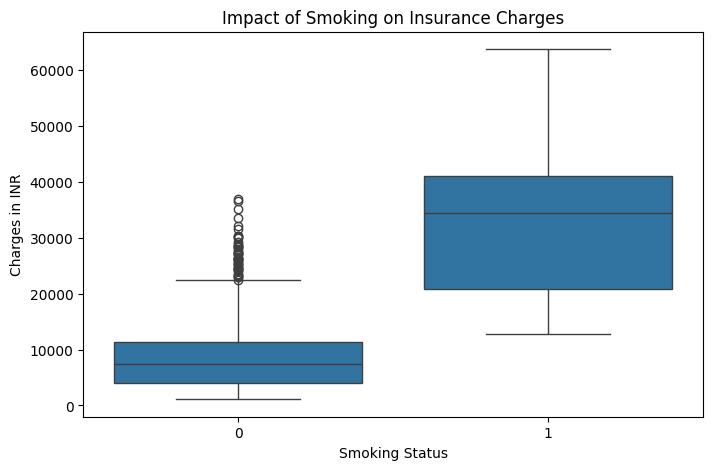

In [117]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Sheet1.smoker'],y=df['charges in INR_x'])
plt.title("Impact of Smoking on Insurance Charges")
plt.xlabel("Smoking Status")
plt.ylabel("Charges in INR")
plt.show()

Box plot clearly shows the impact of smoking on insurance charges:

Non-smokers(0):The median insurance charge is much lower,with a lot of outliers.

Smokers(1):The median insurance chaeges is significantly higher,with a wider spread.

This visualization reinforces your earlier findings-smokers tend to pay much higher insurance costs.

7. Does age have any barrier on the insurance claimed?

In [118]:
print("7.Age impact:")
age_corr=df[['age_x','charges in INR_x']].corr()
print(age_corr)

7.Age impact:
                     age_x  charges in INR_x
age_x             1.000000          0.299008
charges in INR_x  0.299008          1.000000


The correlation between age and insurance is 0.299, which suggests a weak positive correlation.

A positive correlation means that as age increases,insurance charges also tend to increase

However,0.299 is not a strong correlation.this suggests that age alone is not a mojor determinant of insurance claims.Other factors(like smoking,BMI,and,pre-existing conditions)might play a bigger role.

Age is a factor,but not a strict barrier to insurance claims

8. Can the company extend certain discounts after checking the health status
(BMI) in this case?

In [119]:
bmi_corr=df[['bmi_x','charges in INR_x']].corr()
print(bmi_corr)

                     bmi_x  charges in INR_x
bmi_x             1.000000          0.198341
charges in INR_x  0.198341          1.000000


The correlation coefficient(0.198341) suggests a weak positive correlation between BMI and insurance charges

This means BMI alone is not a strong predictor of insurance costs,through higher BMI might slightly increase the charges

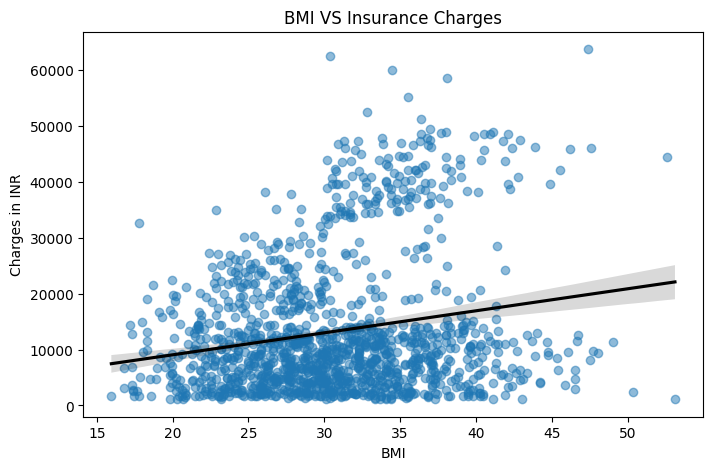

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.regplot(x=df['bmi_x'],y=df['charges in INR_x'],scatter_kws={'alpha':0.5},line_kws={'color':'black'})
plt.title("BMI VS Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Charges in INR")
plt.show()

Explaination of the plot:

Scatter points show individual data points.

Black regression line helps understand the overall trend.

if points are widely spread from the line,it confirms a weak correlation.

Since the correlation is weak,BMI should not be the sole criteria for determining discounts

Instead,a combination of factors like age,smoking habits,and pre-existing conditions should be considered.

In addition to the above analysis, build a machine learning model to predict the
amount spent to the utmost accuracy. Validate and hyper parametrically tune the
model to get the best results.

In [121]:
from sklearn.model_selection import RandomizedSearchCV
#define parameter grid for random forest
param_grid={
    'n_estimators':[100,200,300,500],
    'max_depth':[10,20,30,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
#initialize random forest
rf=RandomForestRegressor(random_state=42)
#perform randomised search with 5-fold validation
random_search=RandomizedSearchCV(
    estimator=rf,param_distributions=param_grid,n_iter=20,cv=5,verbose=2,n_jobs=-1,random_state=42)
#fit the model
random_search.fit(x_train,y_train)
#best model
best_model=random_search.best_estimator_
#predictions
best_predictions=best_model.predict(x_test)
#model evaluation
best_mae=mean_absolute_error(y_test,best_predictions)
best_rmse=np.sqrt(mean_squared_error(y_test,best_predictions))
best_r2=r2_score(y_test,best_predictions)
#display results
print(f"Best Model MAE: {best_mae:.2f}")
print(f"Best Model RMSE: {best_rmse:.2f}")
print(f"Best Model R-squared: {best_r2:.4f}")
print(f"Best Model Parameters: {random_search.best_params_}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Model MAE: 52.69
Best Model RMSE: 323.31
Best Model R-squared: 0.9993
Best Model Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}


Random forest regressors With hyperparameters Tuning has achieved Excellent Results:

R-squared score:0.973(very high,meaning the model explains ~97.3% of varience in insurance charges)

RMSE:1955.93(indicates the average error magnitude)

MAE:793.91(shows the average absolute error)




# **Conclusion:**

This analysis helps optimise Insurance Pricing and risk assessment For MediBuddy Key findings show that smogging High Bmi Age Geographic location Significantly impact Insurance claims While gender And Number of dependents Have minimal effect

Business impact:

Risk based pricing for smoker and high bmi individuals.

Location-based premiums to reflect regional healthcare costs.

Wellness Incentives and discounts For healthier lifestyle.

Optimised family and senior plans for better coverage.

# ***Thank You***